In [1]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
data = Path("Data")

In [3]:
datafiler = os.listdir(data)
datafiler.sort()
datafiler

['.ipynb_checkpoints',
 'befolkningsutvikling_2023_2026_1_3-2_1-1_5.csv',
 'befolkningsutvikling_2023_2123_1_3-2_1.csv',
 'befolkningsutvikling_2023_2123_1_5.csv',
 'befolkningsutvikling_2113_2123_1_5_v2.csv',
 'popfordeling_2023-2023_tfr1_5.csv',
 'popfordeling_2023-2026_tfr1_3.csv',
 'popfordeling_2023-2026_tfr1_5.csv',
 'popfordeling_2023-2026_tfr2_1.csv',
 'popfordeling_2023-2033_tfr1_5.csv',
 'popfordeling_2023-2123_tfr1_3.csv',
 'popfordeling_2023-2123_tfr1_5.csv',
 'popfordeling_2023-2123_tfr2_1.csv',
 'popfordeling_2033-2043_tfr1_5.csv',
 'popfordeling_2043-2053_tfr1_5.csv',
 'popfordeling_2043-2140_tfr2_1.csv',
 'popfordeling_2053-2063_tfr1_5.csv',
 'popfordeling_2063-2073_tfr1_5.csv',
 'popfordeling_2063-2140_tfr2_1.csv',
 'popfordeling_2073-2083_tfr1_5.csv',
 'popfordeling_2083-2093_tfr1_5.csv',
 'popfordeling_2083-2140_tfr2_1.csv',
 'popfordeling_2093-2103_tfr1_5.csv',
 'popfordeling_2103-2113_tfr1_5.csv',
 'popfordeling_2113-2123_tfr1_5.csv',
 'populasjon_2023_tfr1_5.csv',

In [5]:
befolkning = pd.read_csv(data / "befolkningsutvikling_2023_2123_1_5.csv").iloc[:,1:]
befolkning

,år,pop_1.5
0,2023,5488984
1,2024,5527175
2,2025,5565227
3,2026,5580903
4,2027,5596328
...,...,...
96,2119,3903653
97,2120,3873634
98,2121,3843801
99,2122,3814077


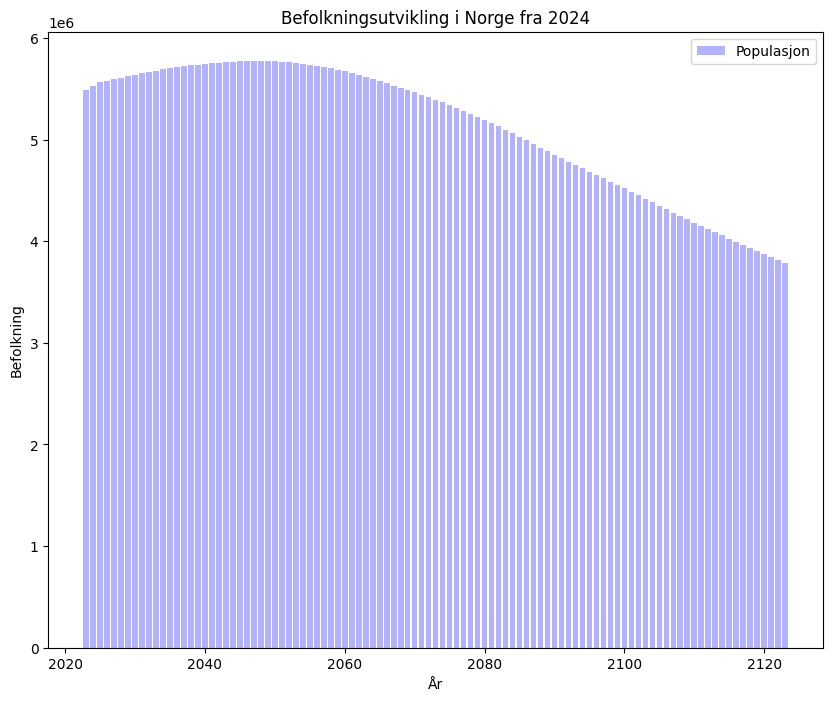

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(befolkning.år, befolkning["pop_1.5"], color='blue', alpha = 0.3, label='Populasjon')

ax.set_ylabel('Befolkning')
ax.set_xlabel('År')
ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()

# ax.line()

In [7]:
populasjon_2026 = pd.read_csv(data / 'popfordeling_2023-2023_tfr1_5.csv')
populasjon_2026

,sex,alder,pop_2023
0,K,0,25310.0
1,K,1,28037.0
2,K,2,26820.0
3,K,3,27466.0
4,K,4,27692.0
...,...,...,...
215,M,105,28.0
216,M,106,NaN
217,M,107,NaN
218,M,108,NaN


In [8]:
pop = pd.read_csv(data / 'popfordeling_2023-2123_tfr1_5.csv')
pop

,sex,alder,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,...,pop_2114,pop_2115,pop_2116,pop_2117,pop_2118,pop_2119,pop_2120,pop_2121,pop_2122,pop_2123
0,K,0,25310.0,27125.0,27102.0,27013.0,26713.0,26473.0,26244.0,26228.0,...,15035.0,14873.0,14880.0,14558.0,14413.0,14317.0,14113.0,14120.0,13946.0,13829.0
1,K,1,28037.0,25505.0,27321.0,27194.0,27103.0,26797.0,26567.0,26324.0,...,15123.0,15065.0,14898.0,14905.0,14586.0,14434.0,14346.0,14143.0,14135.0,13970.0
2,K,2,26820.0,28250.0,25708.0,27425.0,27272.0,27187.0,26889.0,26658.0,...,15154.0,15154.0,15087.0,14932.0,14934.0,14603.0,14458.0,14377.0,14167.0,14153.0
3,K,3,27466.0,27019.0,28464.0,25799.0,27519.0,27351.0,27269.0,26959.0,...,15498.0,15184.0,15180.0,15113.0,14954.0,14952.0,14625.0,14483.0,14403.0,14193.0
4,K,4,27692.0,27677.0,27235.0,28543.0,25891.0,27614.0,27455.0,27356.0,...,15619.0,15516.0,15204.0,15205.0,15138.0,14983.0,14978.0,14646.0,14512.0,14420.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,28.0,NaN,6.0,1.0,1.0,NaN,2.0,1.0,...,8.0,9.0,8.0,7.0,9.0,10.0,9.0,4.0,9.0,6.0
216,M,106,NaN,10.0,NaN,1.0,1.0,NaN,NaN,2.0,...,2.0,3.0,6.0,1.0,1.0,5.0,4.0,3.0,1.0,3.0
217,M,107,NaN,NaN,4.0,NaN,NaN,1.0,NaN,NaN,...,NaN,1.0,2.0,2.0,1.0,NaN,2.0,2.0,2.0,1.0
218,M,108,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN


In [9]:
pop = pop[["sex","alder", "pop_2023", "pop_2050"]]

In [10]:
pop = pop.groupby("alder")[["pop_2023","pop_2050"]].sum()

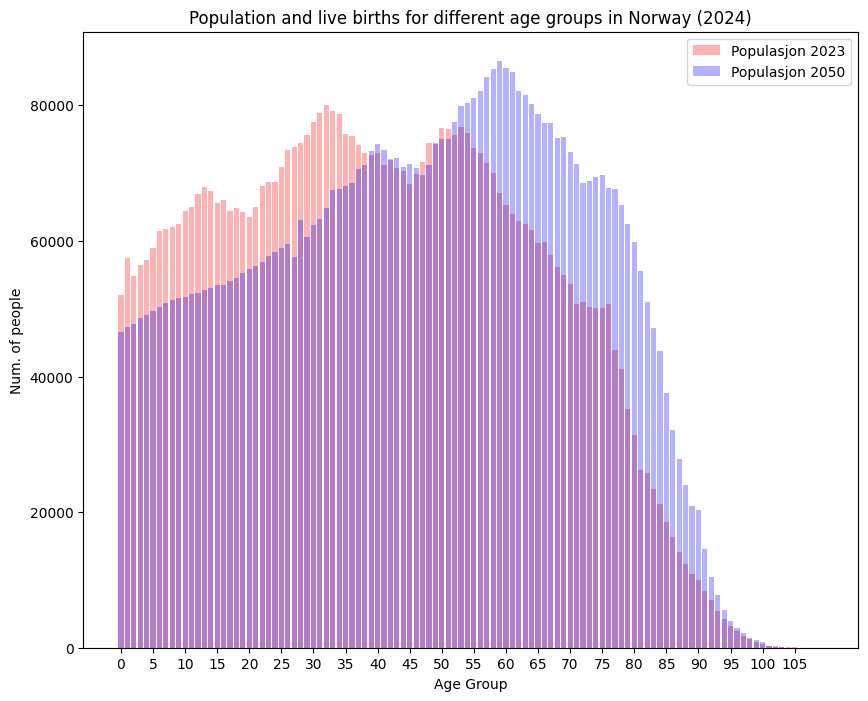

In [11]:
df = pop

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(pop.index, pop['pop_2023'], color='red', alpha = 0.3, label='Populasjon 2023')
ax.bar(pop.index, pop['pop_2050'], color='blue', alpha = 0.3, label='Populasjon 2050')
# ax.barh(kvinner['alder'], -kvinner['2024'], color='orangered', label='Women')

ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(df.index),5))
ax.set_xticklabels(range(0,len(df.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

In [12]:
pop["diff"] = pop["pop_2050"] - pop["pop_2023"]
pop

,pop_2023,pop_2050,diff
alder,,,
0,51991.0,46618.0,-5373.0
1,57415.0,47292.0,-10123.0
2,54778.0,47806.0,-6972.0
3,56455.0,48589.0,-7866.0
4,57146.0,49123.0,-8023.0
...,...,...,...
105,104.0,4.0,-100.0
106,0.0,2.0,2.0
107,0.0,0.0,0.0


In [13]:
pop["diff"].sum()

280307.0

In [14]:
pop = pop.reset_index()
pop

,alder,pop_2023,pop_2050,diff
0,0,51991.0,46618.0,-5373.0
1,1,57415.0,47292.0,-10123.0
2,2,54778.0,47806.0,-6972.0
3,3,56455.0,48589.0,-7866.0
4,4,57146.0,49123.0,-8023.0
...,...,...,...,...
105,105,104.0,4.0,-100.0
106,106,0.0,2.0,2.0
107,107,0.0,0.0,0.0
108,108,0.0,0.0,0.0


In [15]:
bins = list(range(0, 114, 5))

# Lag bins og gi dem lesbare etiketter
pop["aldersgruppe"] = pd.cut(pop["alder"], bins=bins, right=False, include_lowest=True,
                    labels=[f"{i}-{i+4}" for i in range(0, 109, 5)])



In [16]:
age_groups

NameError: name 'age_groups' is not defined

In [17]:
pop_binned = pop.groupby("aldersgruppe")[["pop_2023","pop_2050"]].sum().reset_index()

In [18]:
pop_binned

,aldersgruppe,pop_2023,pop_2050
0,0-4,277785.0,239428.0
1,5-9,306608.0,253695.0
2,10-14,331674.0,261991.0
3,15-19,325360.0,270828.0
4,20-24,333966.0,285142.0
5,25-29,368198.0,299704.0
6,30-34,394345.0,325551.0
7,35-39,370973.0,351647.0
8,40-44,357260.0,362849.0
9,45-49,358569.0,357522.0


In [19]:
pop_binned["diff"] = pop_binned["pop_2050"] - pop_binned["pop_2023"]
pop_binned

,aldersgruppe,pop_2023,pop_2050,diff
0,0-4,277785.0,239428.0,-38357.0
1,5-9,306608.0,253695.0,-52913.0
2,10-14,331674.0,261991.0,-69683.0
3,15-19,325360.0,270828.0,-54532.0
4,20-24,333966.0,285142.0,-48824.0
5,25-29,368198.0,299704.0,-68494.0
6,30-34,394345.0,325551.0,-68794.0
7,35-39,370973.0,351647.0,-19326.0
8,40-44,357260.0,362849.0,5589.0
9,45-49,358569.0,357522.0,-1047.0


In [20]:
pop_binned.iloc[4:8]["diff"].sum()

-205438.0

In [21]:
pop_binned["diff"].sum()

280307.0

In [22]:
år = 2043

fremskrivning_1 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_1["år"] = range(år, år+ len(fremskrivning_21))
fremskrivning_1

NameError: name 'fremskrivning_21' is not defined

In [23]:
år = 2063

fremskrivning_2 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_2["år"] = range(år, år+ len(fremskrivning_2))
fremskrivning_2

,2.1,år
0,5632283,2063
1,5645971,2064
2,5659099,2065
3,5671764,2066
4,5683222,2067
...,...,...
72,4729343,2135
73,4731783,2136
74,4734443,2137
75,4737340,2138


In [24]:
år = 2083

fremskrivning_3 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_3["år"] = range(år, år+ len(fremskrivning_3))
fremskrivning_3

,2.1,år
0,5096082,2083
1,5096219,2084
2,5095355,2085
3,5092995,2086
4,5088512,2087
5,5082098,2088
6,5073755,2089
7,5063418,2090
8,5050959,2091
9,5037069,2092


In [25]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")#.loc[lambda x: x.år <= 2022]

In [26]:
liste_med_fremskrivninger = [fremskrivning_1, fremskrivning_2, fremskrivning_3]

In [27]:
befolkning_for_2023
df1 = pd.DataFrame(befolkning_for_2023).loc[lambda x: x.år < 2024]

In [28]:
fremskrivning_1.loc[0,"år"]

KeyError: 'år'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')
plt.plot(befolkning.år, befolkning["pop_1.5"]) 
# plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')

for df in liste_med_fremskrivninger:
    print(df.head(1))
    plt.plot(df.år, df["2.1"], label=f"Fremskrivning fra {df.loc[0,'år']}")

plt.xlabel('År')
plt.ylabel('Befolkning')
plt.scatter(x=2025, y= befolkning.loc[lambda x: x.år == 2025]["pop_1.5"], color="red", s = 20, zorder = 5, label = "Første fremskrivning med TFR = 1.4")
plt.legend()
plt.ylim(0, 6.5e6)
#plt.grid(True)
plt.show()

In [ ]:
bilder = Path("Figures") / "aldersfordeling"

In [ ]:
plt.savefig(bilder / f"aldersutvikling.jpg", format="jpg", dpi=50)

In [ ]:
popfordeling_2043-2140_tfr2_1.csv